## Scattering by cylinder (Mie Theory)

___

In this problem, we would like to solve for the diffraction of a plane wave from a infinitely long cylinder made from a dielectric or a metal. Since the cylindrical geometry simplifies the problem, the fields can be evaluated analytically instead of doing an FDTD/FEM/FDFD simulation.

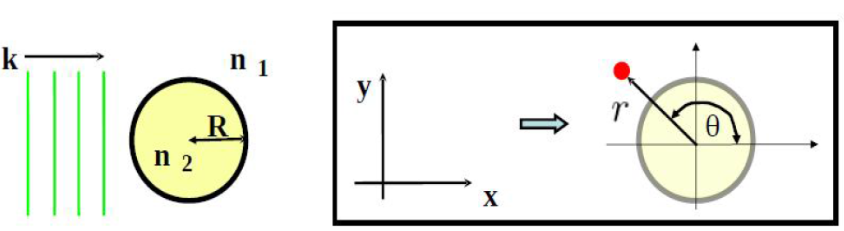

The 2D Helmholtz equation in cylindrical coordinates can be written as:
$$\Large
\frac{1}{rk_0^2}\left(\frac{\partial}{\partial r}\left(r\frac{\partial E(r,\theta,\omega)}{\partial r}\right)+\frac{1}{r}\frac{\partial^2E(r,\theta,\omega)}{\partial \theta^2}\right) + \epsilon(r,\theta,\omega)E(r,\theta,\omega)=0
$$


The solutions to this are Bessel functions. The fields can generally be written in terms of vector cylindrical harmonics (similar to a plane-wave expansion in Cartesian coordinates) as:

$$ \Large
u_{scat}(r,\theta) = \sum_{m=-\infty}^{m=+\infty} i^m a_m H_m^0\left(\frac{2\pi}{\lambda}n_0 r\right) \exp(-im\theta)
$$

$$
\Large
u_{int}(r,\theta) = \sum_{m=-\infty}^{m=+\infty} i^m b_m J_m^0\left(\frac{2\pi}{\lambda}n_c r\right) \exp(-im\theta)
$$


where $J_m^0$ and $H_m^0$ are the Bessel function and Hankel function of the first kind, respectively. $a_m$ and $b_m$ are the expansion coefficients for the fields in the cylindrical basis (similar to plane-wave expansion coefficients). $n_c$ and $n_0$ are the refractive indices of the cylinder and the background, respectively.

Using the interface conditions for the fields, one can solve for these expansion coefficients analytically and obtain:

$$\Large
a_m = \frac{J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right)' J_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right) n_c p_1 - J_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right)' J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right) n_0 p_2}{H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right)' J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right) n_0 p_2 - H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right) J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right)' n_c p_1}
$$

$$\Large
b_m = \frac{H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right)' J_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right) n_0 p_2 - H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right) J_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right)' n_0 p_2}{H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right)' J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right) n_0 p_2 - H_m^0\!\left(\frac{2\pi}{\lambda}n_0 r\right) J_m^0\!\left(\frac{2\pi}{\lambda}n_c r\right)' n_c p_1}
$$

with the polarization dependent factors:
$p_{1,2} =1 $ for TE polarization and $p_1 = n_0^2$ and $p_2 = n_c^2$ for TM polarization. 

#### Fortunately, for this assignment, the scripts for evaluating the fields and the mie coefficients are already provided to you in the `mie_coefficients.py`. Let us use this to explore an example case:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mie_coefficients import Mie_cylindrical

Consider the refractive index of the cylinder to be $n = 2.31$ with radius $r=0.45 \mu \text{m}$. We shall use the wavelength range to be $\lambda=0.5 - 0.7\mu \text{m}$ with TE polarization. We can instantiate the system with the command below:

In [ ]:
mie = Mie_cylindrical(radius=0.45,
                      refractive_index_cylinder=2.31, 
                      m=20, # expansion order until which the summation must be evaluated
                      wavelength=np.linspace(0.5,0.7,51), 
                      polarization='TE')

For these parameters, it is known that at a certain wavelength $\lambda = \lambda_0$ within the given range of $\lambda=0.5 - 0.7\mu \text{m}$, whispersing gallery modes can be excited. This is contrary to geometrical optics where the radius needs to be fairly large compared to the wavelength.

**At this unknown wavelength, the mode number exciting the resonance is $l=\pm8$.**

Text(0, 0.5, 'Scattering efficiency')

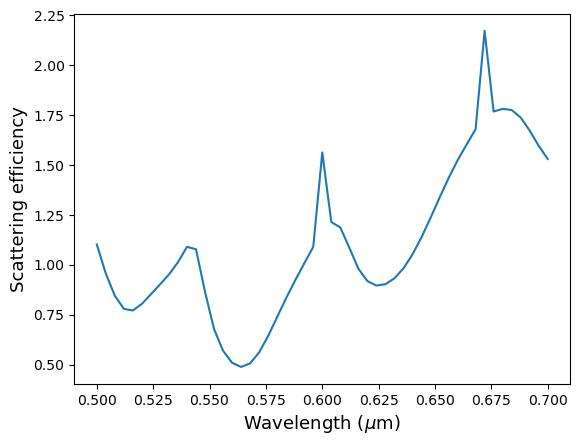

In [10]:
plt.plot(mie.wavelength,mie.scattering_efficiency())
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)
plt.ylabel('Scattering efficiency',fontsize=13)

In [11]:
np.argmin(np.abs(mie.wavelength-0.6))

np.int64(25)

Text(0.5, 1.0, 'Mode energy decomposition for wavelength $\\lambda=\\lambda_0$')

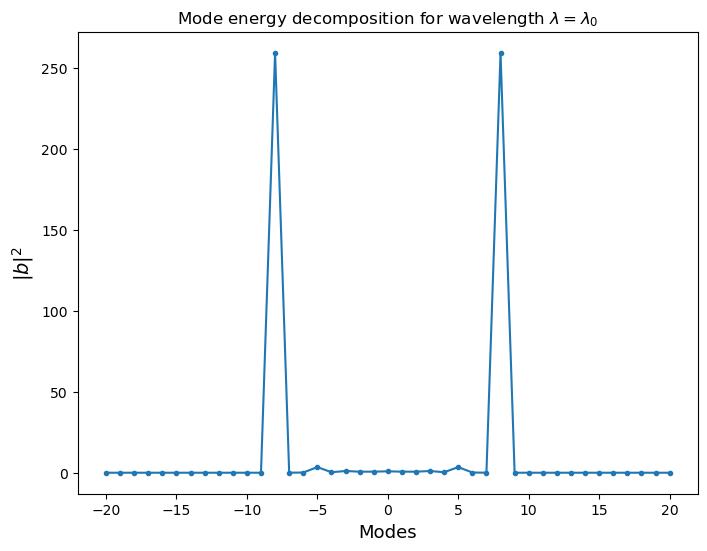

In [12]:
a,b=mie.mie_coefficients() # computes the mie coefficients for each wavelength in the range provided above. Shape : (2m+1 , wavelength.shape)
plt.figure(figsize=(8,6))
plt.plot(mie.M,np.abs(b[:,25])**2,'.-') 
############# ASSIGNMENT! FIND THIS `wavelength_index` ####################################
plt.xlabel('Modes',fontsize=13)
plt.ylabel('$|b|^2$',fontsize=14)
plt.title('Mode energy decomposition for wavelength $\\lambda=\\lambda_0$')

The consequence of this resonance can be seen by illuminating the cylinder by plane waves. The field distributions for all specified wavelength can be obtained by using the function `evaluate_fields()`. 

In [13]:
Lx = 2 # spatial length along x-direction
Ly = 2 # spatial length along y-direction

inc,sc,int_f =mie.evaluate_fields(Lx=Lx,
                                  Ly=Ly,
                                  dx=0.02 # resolution of each grid cell in microns (20 nm)
                                  )

In [14]:
total_fields =  inc + sc + int_f # sum of incident, scattered and internal fields everywhere on the (x,y) grid. Note : the fields are imaginary. Always plot abs(total_fields)^2

In [15]:
total_fields.shape # 100x100 spatial points for 51 wavelengths 

(51, 100, 100)

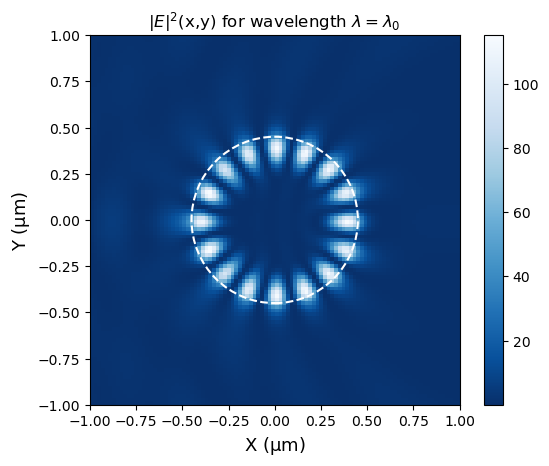

In [16]:
plt.imshow(np.abs(total_fields[25,:,:])**2,
            extent=[-Lx/2,Lx/2,-Ly/2,Ly/2],cmap='Blues_r') 
            ##################### ASSIGNMENT! FIND THIS `wavelength_index` ####################################

plt.gca().add_artist(plt.Circle((0, 0), mie.radius , facecolor='none',edgecolor='w', lw=1.5, ls='--'))
plt.xlabel('X ($\\mathrm{\\mu}$m)',fontsize=13)
plt.ylabel('Y ($\\mathrm{\\mu}$m)',fontsize=13)
plt.title('$|E|^2$(x,y) for wavelength $\\lambda=\\lambda_0$')
plt.colorbar()

## Task : Repeat the same evaluation but now for refractive index = 2.745 and radius = 0.3. At what wavelength is the whispering gallery mode excited? What is the mode number responsible for this resonance?